# p6 DataSet类代码实战

In [1]:
from PIL import Image

你的 notebook 当前工作目录已经是 CSNOTES\pytorch

In [2]:
img_path = r'hymenoptera_data\train\ants\0013035.jpg'

In [3]:
img = Image.open(img_path)

In [4]:
img.size

(768, 512)

In [12]:
img.show()

想读取所有图片，就要获取所有图片的地址

In [5]:
dir_path = r'hymenoptera_data\train\ants'

In [6]:
import os
img_path = os.listdir(dir_path) 
# 列表是按照图片名升序排列的

In [7]:
img_path[2:9]

['1095476100_3906d8afde.jpg',
 '1099452230_d1949d3250.jpg',
 '116570827_e9c126745d.jpg',
 '1225872729_6f0856588f.jpg',
 '1262877379_64fcada201.jpg',
 '1269756697_0bce92cdab.jpg',
 '1286984635_5119e80de1.jpg']

In [8]:
root_dir = r"hymenoptera_data\train"
label_dir = "ants"
path = os.path.join(root_dir, label_dir)

In [9]:
path

'hymenoptera_data\\train\\ants'

In [10]:
img_name = img_path[1]
print(img_name)

1030023514_aad5c608f9.jpg


每个图片的相对路径

In [11]:
img_item_path = os.path.join(root_dir, label_dir, img_name)
print(img_item_path)

hymenoptera_data\train\ants\1030023514_aad5c608f9.jpg


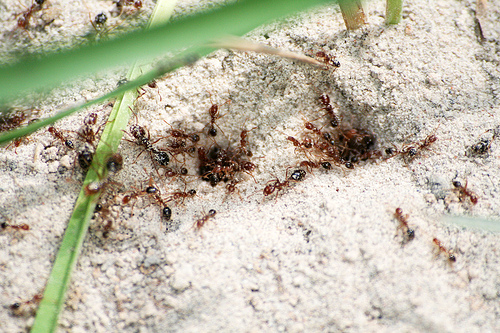

In [12]:
from PIL import Image
img = Image.open(img_item_path)
img

### 演示类

In [13]:
import torch
import PIL
import os

from torch.utils.data import Dataset
from PIL import Image


class MyDataset(Dataset):
    # 根目录地址+标签目录地址 → 图片名称列表'1095476100_3906d8afde.jpg'
    def __init__(self, root_dir, label_dir):
        self.root_dir = root_dir
        self.label_dir = label_dir
        self.path = os.path.join(self.root_dir, self.label_dir)
        self.img_path = os.listdir(self.path)

    # 获取所有图片的地址
    def __getitem__(self, idx):
        img_name = self.img_path[idx]
        # 每个图片的相对路径
        img_item_path = os.path.join(self.root_dir, self.label_dir,  img_name)
        # hymenoptera_data\train\ants\1030023514_aad5c608f9.jpg
        img = Image.open(img_item_path)
        label = self.label_dir
        return img, label

    def __len__(self):
        return len(self.img_path)

**路径问题！！！**       
最好改成绝对路径，因为虽然数据和py文件在同一目录，但是目前工作目录是csnotes，如果当前工作目录就是pytorch，可使用相对路径

In [ ]:

#root_dir = "F:\\csnotes\\pytorch\\hymenoptera_data\\train"
root_dir = "hymenoptera_data\\train"
ants_label_dir="ants"
ants_dataset = MyDataset(root_dir, ants_label_dir)

In [16]:
ants_dataset[0]
# 返回的是一个元组，包含图片和标签

(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=768x512 at 0x1856490B588>,
 'ants')

In [17]:
img0, label0 = ants_dataset[0]

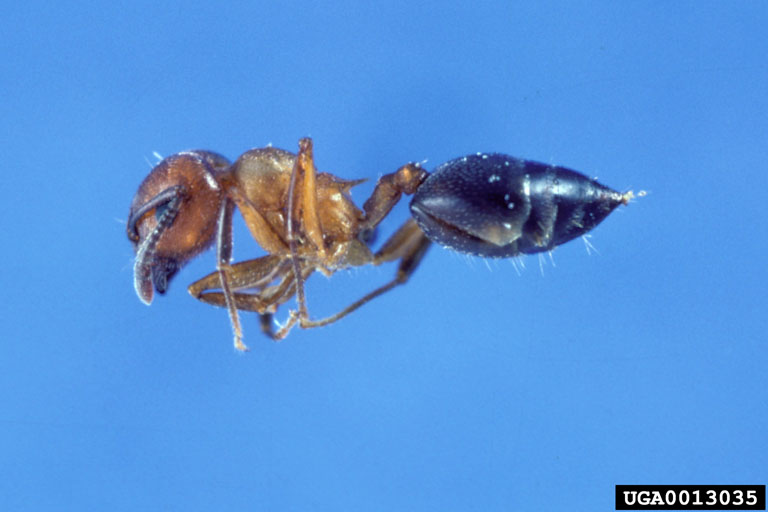

In [18]:
img0

蜜蜂演示

In [19]:
# root_dir = "F:\\csnotes\\pytorch\\hymenoptera_data\\train"
root_dir = "hymenoptera_data\\train"
bees_label_dir="bees"
bees_dataset = MyDataset(root_dir, bees_label_dir)
img0, label0 = bees_dataset[0]
print(label0)

bees


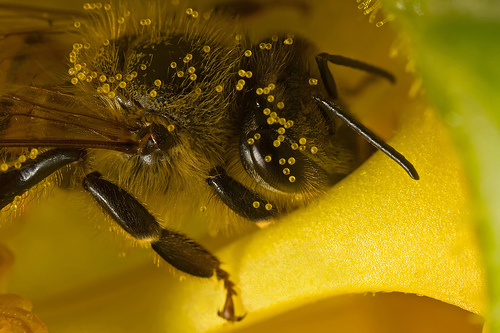

In [20]:
img0

### 完整的train数据集

In [21]:
root_dir = "hymenoptera_data\\train"
ants_label_dir="ants"
ants_dataset = MyDataset(root_dir, ants_label_dir)
# img0, label0 = ants_dataset[0]
# img0.show()
# print(label0)
bees_label_dir="bees"
bees_dataset = MyDataset(root_dir, bees_label_dir)

train_dataset = ants_dataset + bees_dataset

In [22]:
len(train_dataset)

245

# TensorBoard使用

In [26]:
import torch
from torch.utils.tensorboard import SummaryWriter

## 1. 演示add_scalar()

In [ ]:
# 先创建一个实例
writer = SummaryWriter("logs")
# writer.add_image()
# y = 2x
for i in range(100):
    writer.add_scalar("y=2x", 2*i, i)
writer.close()

## logs文件夹里又出现了一个新的文件

## 2. 演示add_image()

In [28]:
image_path = r"hymenoptera_data\train\ants\0013035.jpg"

In [ ]:
from PIL import Image
img = Image.open(image_path)
print(type(img))
# 不满足add_image()的输入要求，需要转换
# 使用opencv把图片读取成numpy型


<class 'PIL.JpegImagePlugin.JpegImageFile'>


转换图片类型

In [31]:
import numpy as np

In [33]:
img_array = np.array(img)
print(type(img_array))
print(img_array.shape)

<class 'numpy.ndarray'>
(512, 768, 3)


# Transforms使用

In [6]:
from PIL import Image

from torchvision import transforms


# 1. transforms如何使用
# 2. tensor数据类型

# 绝对路径 F:\csnotes\pytorch\hymenoptera_data\train\ants\0013035.jpg
# 相对路径 hymenoptera_data\train\ants\0013035
img_path = r"hymenoptera_data\train\ants\0013035.jpg"
img = Image.open(img_path)
print(img)

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=768x512 at 0x26BF09F2780>


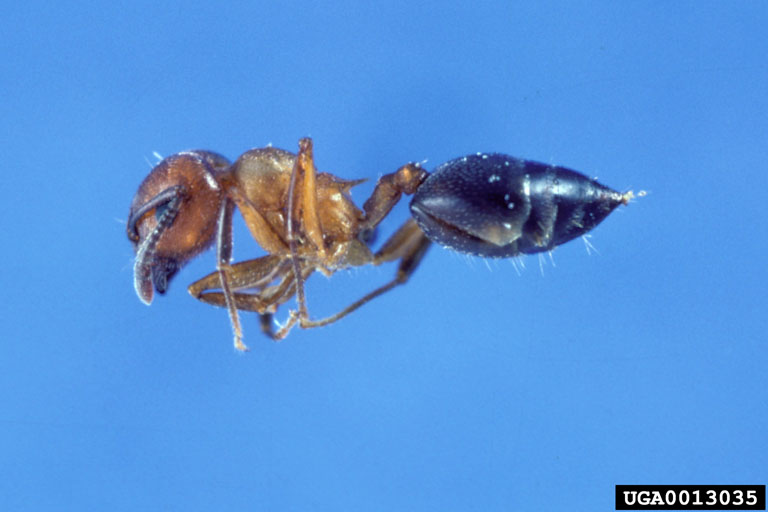

In [7]:
img

In [8]:
# 先实例化一个类
tensor_trans = transforms.ToTensor()
# 再调用实例化的对象
tensor_img = tensor_trans(img)
print(tensor_img)

tensor([[[0.3137, 0.3137, 0.3137,  ..., 0.3176, 0.3098, 0.2980],
         [0.3176, 0.3176, 0.3176,  ..., 0.3176, 0.3098, 0.2980],
         [0.3216, 0.3216, 0.3216,  ..., 0.3137, 0.3098, 0.3020],
         ...,
         [0.3412, 0.3412, 0.3373,  ..., 0.1725, 0.3725, 0.3529],
         [0.3412, 0.3412, 0.3373,  ..., 0.3294, 0.3529, 0.3294],
         [0.3412, 0.3412, 0.3373,  ..., 0.3098, 0.3059, 0.3294]],

        [[0.5922, 0.5922, 0.5922,  ..., 0.5961, 0.5882, 0.5765],
         [0.5961, 0.5961, 0.5961,  ..., 0.5961, 0.5882, 0.5765],
         [0.6000, 0.6000, 0.6000,  ..., 0.5922, 0.5882, 0.5804],
         ...,
         [0.6275, 0.6275, 0.6235,  ..., 0.3608, 0.6196, 0.6157],
         [0.6275, 0.6275, 0.6235,  ..., 0.5765, 0.6275, 0.5961],
         [0.6275, 0.6275, 0.6235,  ..., 0.6275, 0.6235, 0.6314]],

        [[0.9137, 0.9137, 0.9137,  ..., 0.9176, 0.9098, 0.8980],
         [0.9176, 0.9176, 0.9176,  ..., 0.9176, 0.9098, 0.8980],
         [0.9216, 0.9216, 0.9216,  ..., 0.9137, 0.9098, 0.

In [9]:
print(tensor_img.shape)

torch.Size([3, 512, 768])


tensor数据类型

In [10]:
import cv2

In [ ]:
cv_img = cv2.imread(img_path)
# cv2把图片转化成了numpy数组


# 常用的Transforms

In [13]:
from PIL import Image

img = Image.open(r'hymenoptera_data\train\bees\16838648_415acd9e3f.jpg')
print(img)

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x450 at 0x26BF0FC9390>


### ToTensor()

In [14]:
trans_totensor = transforms.ToTensor()
img_tensor = trans_totensor(img)
print(img_tensor)

tensor([[[0.0980, 0.0863, 0.0902,  ..., 0.0314, 0.0314, 0.0431],
         [0.0784, 0.0863, 0.0863,  ..., 0.0235, 0.0196, 0.0196],
         [0.0510, 0.0784, 0.0863,  ..., 0.0431, 0.0353, 0.0392],
         ...,
         [0.7765, 0.7804, 0.6941,  ..., 0.7529, 0.7333, 0.7804],
         [0.6784, 0.8000, 0.7529,  ..., 0.7490, 0.7098, 0.7961],
         [0.7882, 0.7176, 0.6431,  ..., 0.7373, 0.6824, 0.7529]],

        [[0.0863, 0.0667, 0.0667,  ..., 0.0706, 0.0706, 0.0667],
         [0.0824, 0.0863, 0.0824,  ..., 0.0510, 0.0471, 0.0392],
         [0.0863, 0.1020, 0.0941,  ..., 0.0510, 0.0431, 0.0392],
         ...,
         [0.8980, 0.9137, 0.8392,  ..., 0.8941, 0.8510, 0.8745],
         [0.7882, 0.9020, 0.8510,  ..., 0.8627, 0.8118, 0.8902],
         [0.8980, 0.8196, 0.7412,  ..., 0.8510, 0.7843, 0.8471]],

        [[0.1216, 0.0902, 0.0667,  ..., 0.0392, 0.0392, 0.0510],
         [0.0980, 0.0941, 0.0745,  ..., 0.0235, 0.0196, 0.0235],
         [0.0667, 0.0863, 0.0745,  ..., 0.0314, 0.0235, 0.

## Normalize()

In [15]:
trans_norm = transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
img_norm = trans_norm(img_tensor)
print(img_norm)

tensor([[[-0.8039, -0.8275, -0.8196,  ..., -0.9373, -0.9373, -0.9137],
         [-0.8431, -0.8275, -0.8275,  ..., -0.9529, -0.9608, -0.9608],
         [-0.8980, -0.8431, -0.8275,  ..., -0.9137, -0.9294, -0.9216],
         ...,
         [ 0.5529,  0.5608,  0.3882,  ...,  0.5059,  0.4667,  0.5608],
         [ 0.3569,  0.6000,  0.5059,  ...,  0.4980,  0.4196,  0.5922],
         [ 0.5765,  0.4353,  0.2863,  ...,  0.4745,  0.3647,  0.5059]],

        [[-0.8275, -0.8667, -0.8667,  ..., -0.8588, -0.8588, -0.8667],
         [-0.8353, -0.8275, -0.8353,  ..., -0.8980, -0.9059, -0.9216],
         [-0.8275, -0.7961, -0.8118,  ..., -0.8980, -0.9137, -0.9216],
         ...,
         [ 0.7961,  0.8275,  0.6784,  ...,  0.7882,  0.7020,  0.7490],
         [ 0.5765,  0.8039,  0.7020,  ...,  0.7255,  0.6235,  0.7804],
         [ 0.7961,  0.6392,  0.4824,  ...,  0.7020,  0.5686,  0.6941]],

        [[-0.7569, -0.8196, -0.8667,  ..., -0.9216, -0.9216, -0.8980],
         [-0.8039, -0.8118, -0.8510,  ..., -0

##  Resize()

In [18]:
print(img.size)

(500, 450)


In [19]:
print(img.size)
trans_resize = transforms.Resize((512, 512))
img_resize = trans_resize(img)
print(img_resize)

(500, 450)
<PIL.Image.Image image mode=RGB size=512x512 at 0x26BF0FD0940>


## Compose()组合使用

In [20]:
trans_resize_2 = transforms.Resize(512)
# PIL-> PIL->tensor
trans_compose = transforms.Compose([trans_resize_2, trans_totensor])
# compose需要参数列表
img_resize_2 = trans_compose(img)
print(img_resize_2.shape)

torch.Size([3, 512, 568])


## RandomCrop()随机裁剪图片

In [22]:
trans_random = transforms.RandomCrop(224)
trans_compose_2 = transforms.Compose([trans_random, trans_totensor])
# 展示随机裁剪结果
for i in range(10):
    img_crop =  trans_compose_2(img)
    # writer.add_image("randomcrop", img_crop, i)
    print(img_crop.shape)

torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
